In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import TargetEncoder
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from autogluon.tabular import TabularPredictor

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train = pd.read_csv('data/train.csv')
X_test = pd.read_csv('data/test.csv')
y_train = X_train.pop('Churn') 

In [3]:
X_train = X_train.drop(columns=['id'])
X_test = X_test.drop(columns=['id'])

#### Używanie podzbioru dla szybszych obliczeń - sprawdzamy dodanie których kolumn (interakcji/nowych cech) najbardziej zwiększa roc auc

In [4]:
X_sample, _, y_sample, _ = train_test_split(
    X_train, 
    y_train, 
    train_size=0.10,   
    random_state=42,   
    stratify=y_train   
)

In [5]:
y_sample = y_sample.map({'No': 0, 'Yes': 1})
categorical_cols = X_sample.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
X_cv = X_sample.copy()
X_cv['tenure_safe'] = X_cv['tenure'].replace(0, 0.001)
avg_historical_charge_cv = X_cv['TotalCharges'] / X_cv['tenure_safe']
X_cv['Int_PriceShockRatio'] = X_cv['MonthlyCharges'] / (avg_historical_charge_cv + 0.001)
X_cv['Int_CostPerTenure'] = X_cv['MonthlyCharges'] / X_cv['tenure_safe']
X_cv['Int_ImpliedTenureDiff'] = (X_cv['TotalCharges'] / (X_cv['MonthlyCharges'] + 0.001)) - X_cv['tenure']
X_cv['Int_CumulativeBurden'] = X_cv['TotalCharges'] * X_cv['MonthlyCharges']
base_cat_features = categorical_cols
### WAŻNE: SeniorCitizen jest typu, ale to kategoria
base_cat_features.append('SeniorCitizen')

In [6]:
candidate_numeric_features = [
    'tenure', 'MonthlyCharges', 'TotalCharges', 
    'Int_PriceShockRatio', 'Int_CostPerTenure', 
    'Int_ImpliedTenureDiff', 'Int_CumulativeBurden'
]

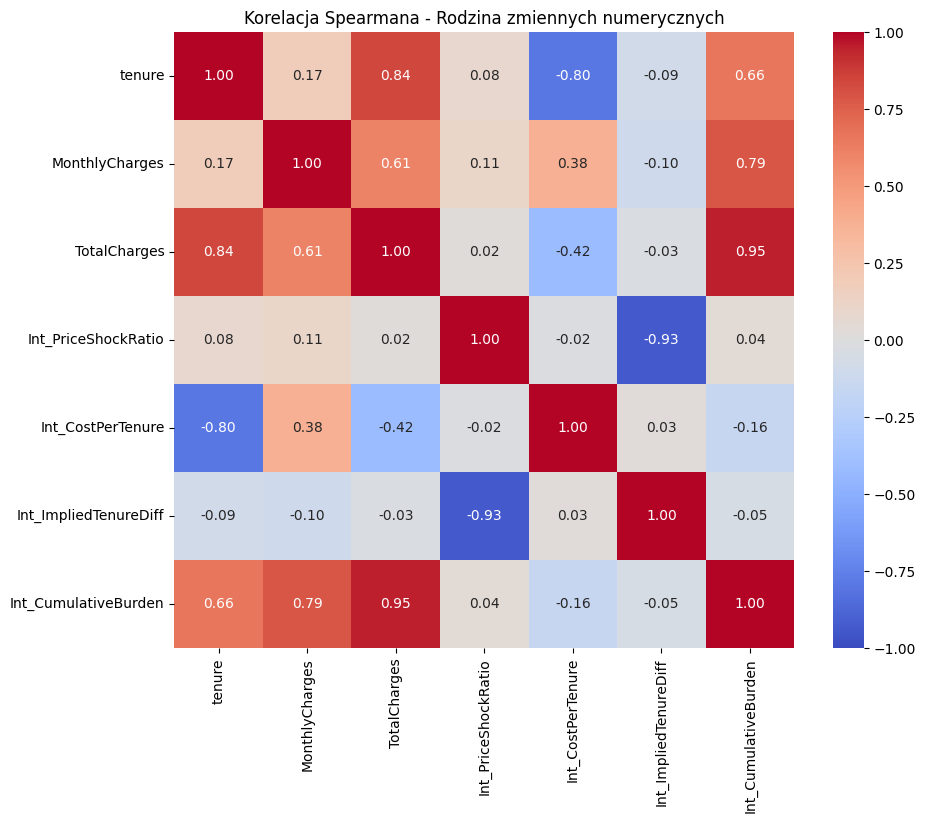

In [7]:
corr_matrix = X_cv[candidate_numeric_features].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Korelacja Spearmana - Rodzina zmiennych numerycznych")
plt.show()

In [8]:
def get_cv_score(features_to_test, X_data, y_data):
    X = X_data[base_cat_features + features_to_test]
    y = y_data
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', TargetEncoder(random_state=42), base_cat_features),
            ('num', 'passthrough', features_to_test)
        ]
    )
    
    model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42, n_jobs=-1)
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')
    return np.mean(scores)

print("Rozpoczynam zindywidualizowaną selekcję zmiennych...\n")

best_features = []
best_score = 0.0

for feature in candidate_numeric_features:
    score = get_cv_score([feature], X_cv, y_sample)
    if score > best_score:
        best_score = score
        best_initial_feature = feature

best_features.append(best_initial_feature)
candidate_numeric_features.remove(best_initial_feature)
print(f"Baza: Tylko kategoryczne + '{best_initial_feature}' -> ROC AUC: {best_score:.5f}")
improvement = True
while improvement and candidate_numeric_features:
    improvement = False
    best_step_score = best_score
    best_feature_to_add = None
    
    for feature in candidate_numeric_features:
        current_test_features = best_features + [feature]
        score = get_cv_score(current_test_features, X_cv, y_sample)
        
        if score > best_step_score:
            best_step_score = score
            best_feature_to_add = feature
            improvement = True
            
    if improvement:
        best_features.append(best_feature_to_add)
        candidate_numeric_features.remove(best_feature_to_add)
        best_score = best_step_score
        print(f"Dodano '{best_feature_to_add}' -> Nowy najlepszy ROC AUC: {best_score:.5f}")
    else:
        print("\nŻadna z pozostałych zmiennych nie poprawia już wyniku.")

print("\n--- PODSUMOWANIE ---")
print(f"Optymalny zestaw numeryczny (maksymalizujący ROC AUC): {best_features}")
print(f"Ostateczny wynik OOF ROC AUC: {best_score:.5f}")
print(f"Zmienne odrzucone jako szum/redundantne: {candidate_numeric_features}")

Rozpoczynam zindywidualizowaną selekcję zmiennych...

Baza: Tylko kategoryczne + 'Int_CostPerTenure' -> ROC AUC: 0.90750
Dodano 'tenure' -> Nowy najlepszy ROC AUC: 0.90811
Dodano 'MonthlyCharges' -> Nowy najlepszy ROC AUC: 0.90820

Żadna z pozostałych zmiennych nie poprawia już wyniku.

--- PODSUMOWANIE ---
Optymalny zestaw numeryczny (maksymalizujący ROC AUC): ['Int_CostPerTenure', 'tenure', 'MonthlyCharges']
Ostateczny wynik OOF ROC AUC: 0.90820
Zmienne odrzucone jako szum/redundantne: ['TotalCharges', 'Int_PriceShockRatio', 'Int_ImpliedTenureDiff', 'Int_CumulativeBurden']


Wygląda na to, że trzy najlepsze zmienne to CostPerTenure, tenure oraz MonthlyCharges

### Sprawdzenie interakcji cech kategorycznych

#### Ad. 1) Czy dla Streaming Movies/Tv wystarczy dla polepszenia predykcji sama informacja czy nie było internet service

In [9]:
cross_tab = pd.crosstab(X_train['InternetService'], X_train['StreamingTV'])
cross_tab

StreamingTV,No,No internet service,Yes
InternetService,,,
DSL,104608,0,76473
Fiber optic,108558,0,163828
No,0,140727,0


In [10]:
base_cat_features = categorical_cols.copy()
best_num = ['Int_CostPerTenure', 'tenure', 'MonthlyCharges']
cols_to_drop = ['StreamingTV', 'StreamingMovies', 'MultipleLines']
print(f"\n--- TESTOWANIE USUNIĘCIA PREDYKTORÓW: {cols_to_drop} ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_full = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Pełna baza (Wszystkie predyktory) -> ROC AUC: {score_1_full:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_drop]
score_2_dropped = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Baza odchudzona (BEZ 3 predyktorów) -> ROC AUC: {score_2_dropped:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE USUNIĘCIA PREDYKTORÓW: ['StreamingTV', 'StreamingMovies', 'MultipleLines'] ---
1. Pełna baza (Wszystkie predyktory) -> ROC AUC: 0.90820
2. Baza odchudzona (BEZ 3 predyktorów) -> ROC AUC: 0.90788


#### Widać, że cała wiedza zawarta w StreamingTV jest zawarta w InternetService, ale usunięcie ich zmniejsza ROC AUC

#### Ad. 2) Czy zsumowanie liczby usług będzie lepsze niż trzymanie ich razem?

In [11]:
services_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport']
X_cv['Num_Services'] = (X_cv[services_cols] == 'Yes').sum(axis=1)
best_num = ['Int_CostPerTenure', 'tenure', 'MonthlyCharges']
print("--- TESTOWANIE NOWEJ ZMIENNEJ 'Num_Services' ---")
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginalne 4 kategorie (Brak Num_Services) -> ROC AUC: {score_1:.5f}")
score_2 = get_cv_score(best_num + ['Num_Services'], X_cv, y_sample)
print(f"2. Oryginalne 4 kategorie + Num_Services -> ROC AUC: {score_2:.5f}")
oryginalne_kategorie = base_cat_features.copy() 
base_cat_features = [col for col in oryginalne_kategorie if col not in services_cols] 
score_3 = get_cv_score(best_num + ['Num_Services'], X_cv, y_sample)
print(f"3. TYLKO Num_Services (Wyrzucone 4 oryginały) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie

--- TESTOWANIE NOWEJ ZMIENNEJ 'Num_Services' ---
1. Oryginalne 4 kategorie (Brak Num_Services) -> ROC AUC: 0.90820
2. Oryginalne 4 kategorie + Num_Services -> ROC AUC: 0.90810
3. TYLKO Num_Services (Wyrzucone 4 oryginały) -> ROC AUC: 0.90832


#### Zamiana na Num_Services polepsza predykcyjność 

In [12]:
base_cat_features.remove('OnlineSecurity')
base_cat_features.remove('OnlineBackup')
base_cat_features.remove('DeviceProtection')
base_cat_features.remove('TechSupport')
base_cat_features.append('Num_Services')

#### Ad. 3) Sprawdzenie czy Partners i Dependants dają lepsze wyniki

In [13]:
family_cols = ['Partner', 'Dependents']
X_cv['FamilySize'] = (X_cv[family_cols] == 'Yes').sum(axis=1)
best_num = ['Int_CostPerTenure', 'tenure', 'MonthlyCharges']
print("--- TESTOWANIE NOWEJ ZMIENNEJ 'FamilySize' (Partner + Dependents) ---")
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały (Brak FamilySize) -> ROC AUC: {score_1:.5f}")
score_2 = get_cv_score(best_num + ['FamilySize'], X_cv, y_sample)
print(f"2. Oryginały + FamilySize -> ROC AUC: {score_2:.5f}")
oryginalne_kategorie = base_cat_features.copy() 
base_cat_features = [col for col in oryginalne_kategorie if col not in family_cols] 
score_3 = get_cv_score(best_num + ['FamilySize'], X_cv, y_sample)
print(f"3. TYLKO FamilySize (Wyrzucone oryginały) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie

--- TESTOWANIE NOWEJ ZMIENNEJ 'FamilySize' (Partner + Dependents) ---
1. Oryginały (Brak FamilySize) -> ROC AUC: 0.90837
2. Oryginały + FamilySize -> ROC AUC: 0.90830
3. TYLKO FamilySize (Wyrzucone oryginały) -> ROC AUC: 0.90820


#### Nowa zmienna nie pomaga, zachowuje początkowe kategorie

In [14]:
X_cv.drop(columns=['FamilySize'], inplace=True)

#### Ad. 4) Phone Service + Internet Service

In [15]:
X_cv['Phone_Internet_Combo'] = X_cv['PhoneService'].astype(str) + "_" + X_cv['InternetService'].astype(str)
cols_to_combine = ['PhoneService', 'InternetService', 'MonthlyCharges']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Phone_Internet_Combo' ---")
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1:.5f}")
base_cat_features = oryginalne_kategorie + ['Phone_Internet_Combo']
score_2 = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine] + ['Phone_Internet_Combo']
score_3 = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Phone_Internet_Combo' ---
1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.90837
2. Oryginały + Combo -> ROC AUC: 0.90818
3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.90839


#### Nowe zmienna jest lepsza niż poprzednie

In [16]:
base_cat_features.remove('PhoneService')
base_cat_features.remove('InternetService')
base_cat_features.append('Phone_Internet_Combo')


#### Ad. 5) Paperless Billing oraz Senior Citizen

In [17]:
X_cv['Paperless_Senior_Combo'] = X_cv['PaperlessBilling'].astype(str) + "_" + X_cv['SeniorCitizen'].astype(str)
cols_to_combine_3 = ['PaperlessBilling', 'SeniorCitizen', 'MonthlyCharges']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Paperless_Senior_Combo' ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_paperless = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1_paperless:.5f}")
base_cat_features = oryginalne_kategorie + ['Paperless_Senior_Combo']
score_2_paperless = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2_paperless:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine_3] + ['Paperless_Senior_Combo']
score_3_paperless = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3_paperless:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ KATEGORYCZNEJ 'Paperless_Senior_Combo' ---
1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.90839
2. Oryginały + Combo -> ROC AUC: 0.90858
3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.90832


#### Dodanie zmiennej Paperless_Senior_Combo polepsza predykcyjność

In [18]:
base_cat_features.append('Paperless_Senior_Combo')

#### Ad. 6) Profil płatnika - PaymentMethod + PaperlessBilling

In [19]:
X_cv['Payment_Paperless_Combo'] = X_cv['PaymentMethod'].astype(str) + "_" + X_cv['PaperlessBilling'].astype(str)
cols_to_combine_payment = ['PaymentMethod', 'PaperlessBilling']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ: 'Payment_Paperless_Combo' ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_pay = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1_pay:.5f}")
base_cat_features = oryginalne_kategorie + ['Payment_Paperless_Combo']
score_2_pay = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2_pay:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine_payment] + ['Payment_Paperless_Combo']
score_3_pay = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3_pay:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ: 'Payment_Paperless_Combo' ---
1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.90858
2. Oryginały + Combo -> ROC AUC: 0.90820
3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.90847


Zmienna nic nie wnosi

#### Ad. 7) Samotny Senior

In [20]:
X_cv['Senior_Partner_Combo'] = X_cv['SeniorCitizen'].astype(str) + "_" + X_cv['Partner'].astype(str)
cols_to_combine_senior = ['SeniorCitizen', 'Partner']
print("\n--- TESTOWANIE NOWEJ ZMIENNEJ: 'Senior_Partner_Combo' ---")
oryginalne_kategorie = base_cat_features.copy() 
score_1_sen = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Oryginały osobno (Brak Combo) -> ROC AUC: {score_1_sen:.5f}")
base_cat_features = oryginalne_kategorie + ['Senior_Partner_Combo']
score_2_sen = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Oryginały + Combo -> ROC AUC: {score_2_sen:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in cols_to_combine_senior] + ['Senior_Partner_Combo']
score_3_sen = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: {score_3_sen:.5f}")
base_cat_features = oryginalne_kategorie


--- TESTOWANIE NOWEJ ZMIENNEJ: 'Senior_Partner_Combo' ---
1. Oryginały osobno (Brak Combo) -> ROC AUC: 0.90858
2. Oryginały + Combo -> ROC AUC: 0.90857
3. TYLKO Combo (Wyrzucone oryginały) -> ROC AUC: 0.90837


Brak poprawy

#### Binning zmiennej tenure ze zmienną Contract

In [21]:
tree_bin = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_bin.fit(X_cv[['tenure']], y_sample)
thresholds = tree_bin.tree_.threshold
print(thresholds)
splits = [th for th in thresholds if th != -2]
splits.sort()

print(f"Optymalne progi podziału znalezione przez model: {splits}")
opt_przedzialy = [-np.inf] + splits + [np.inf]
opt_etykiety = [f"Bin_{i+1}" for i in range(len(opt_przedzialy) - 1)]
X_cv['tenure_binned_opt'] = pd.cut(X_cv['tenure'], bins=opt_przedzialy, labels=opt_etykiety)
X_cv['Tenure_Contract_Combo_Opt'] = X_cv['tenure_binned_opt'].astype(str) + "_" + X_cv['Contract'].astype(str)
print("\n--- TESTOWANIE: OPTYMALNY BINNING TENURE + CONTRACT ---")
oryginalne_kategorie = base_cat_features.copy()
kolumny_do_wyrzucenia = ['Contract']
score_1 = get_cv_score(best_num, X_cv, y_sample)
print(f"1. Baza (Oryginalny Contract i tenure) -> ROC AUC: {score_1:.5f}")
base_cat_features = oryginalne_kategorie + ['Tenure_Contract_Combo_Opt']
score_2 = get_cv_score(best_num, X_cv, y_sample)
print(f"2. Baza + Optymalne Combo -> ROC AUC: {score_2:.5f}")
base_cat_features = [col for col in oryginalne_kategorie if col not in kolumny_do_wyrzucenia] + ['Tenure_Contract_Combo_Opt']
score_3 = get_cv_score(best_num, X_cv, y_sample)
print(f"3. TYLKO Optymalne Combo (Wyrzucony Contract) -> ROC AUC: {score_3:.5f}")
base_cat_features = oryginalne_kategorie

[17.5  1.5 -2.  -2.  42.5 -2.  -2. ]
Optymalne progi podziału znalezione przez model: [np.float64(1.5), np.float64(17.5), np.float64(42.5)]

--- TESTOWANIE: OPTYMALNY BINNING TENURE + CONTRACT ---
1. Baza (Oryginalny Contract i tenure) -> ROC AUC: 0.90858
2. Baza + Optymalne Combo -> ROC AUC: 0.90888
3. TYLKO Optymalne Combo (Wyrzucony Contract) -> ROC AUC: 0.90873


#### Dodanie tej zmiennej zwiększa predykcyjność

In [22]:
base_cat_features.append('Tenure_Contract_Combo_Opt')

#### Budowa zbioru danych

In [23]:
final_features = base_cat_features + best_num
X_train_final = X_cv[final_features].copy()
df_train_final = X_train_final.copy()
df_train_final['Churn'] = y_sample.values 
print(f"Ostateczna liczba predyktorów: {X_train_final.shape[1]}")
print(f"Wybrane kolumny:\n{X_train_final.columns.tolist()}")

Ostateczna liczba predyktorów: 17
Wybrane kolumny:
['gender', 'Partner', 'Dependents', 'MultipleLines', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'SeniorCitizen', 'Num_Services', 'Phone_Internet_Combo', 'Paperless_Senior_Combo', 'Tenure_Contract_Combo_Opt', 'Int_CostPerTenure', 'tenure', 'MonthlyCharges']


#### Pipeline do treningu - autogluon oraz przetworzenie dla całego zbioru danych

In [28]:
def prepare_data_for_autogluon(X_df):
    df = X_df.copy()
    services = ['OnlineSecurity', 'OnlineBackup', 
                'DeviceProtection', 'TechSupport']
    df['Num_Services'] = (df[services] == 'Yes').sum(axis=1)
    df['Int_CostPerTenure'] = df['MonthlyCharges'] / df['tenure']
    df['Phone_Internet_Combo'] = df['PhoneService'].astype(str) + "_" + df['InternetService'].astype(str)
    df['Paperless_Senior_Combo'] = df['PaperlessBilling'].astype(str) + "_" + df['SeniorCitizen'].astype(str)
    splits = [-np.inf, 1.5, 17.5, 42.5, np.inf]
    df['tenure_binned'] = pd.cut(df['tenure'], bins=splits, labels=['B1', 'B2', 'B3', 'B4'])
    df['Tenure_Contract_Combo_Opt'] = df['tenure_binned'].astype(str) + "_" + df['Contract'].astype(str)

    final_cols = [
        'gender', 'Partner', 'Dependents', 'MultipleLines', 'StreamingTV', 
        'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 
        'SeniorCitizen', 'Num_Services', 'Phone_Internet_Combo', 
        'Paperless_Senior_Combo', 'Tenure_Contract_Combo_Opt', 
        'Int_CostPerTenure', 'tenure', 'MonthlyCharges'
    ]
    
    return df[final_cols]

In [29]:
X_train_processed = prepare_data_for_autogluon(X_train)
y_train_mapped = y_train.map({'Yes': 1, 'No': 0})
train_data = X_train_processed.copy()
train_data['Churn'] = y_train_mapped

print(f"Gotowa ramka treningowa: {train_data.shape[0]} wierszy, {train_data.shape[1]} kolumn.")

Gotowa ramka treningowa: 594194 wierszy, 18 kolumn.


In [30]:
label = 'Churn'

In [31]:
X_test_processed = prepare_data_for_autogluon(X_test)
test_data = X_test_processed.copy()
print(f"Gotowa ramka testowa: {test_data.shape[0]} wierszy, {test_data.shape[1]} kolumn.")

Gotowa ramka testowa: 254655 wierszy, 17 kolumn.


In [32]:
predictor = TabularPredictor(
    label=label, 
    eval_metric='roc_auc' 
).fit(
    train_data,
    presets='best_quality',  
    time_limit=600,    
    num_stack_levels=1,    
    excluded_model_types=['KNN'], 
    verbosity=2
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260309_074202"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.13.5
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.8.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       3.51 GB / 15.70 GB (22.3%)
Disk Space Avail:   7.00 GB / 406.19 GB (1.7%)
	We recommend a minimum available disk space of 10 GB, and large datasets may require more.
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Setting dynamic_stacking from 'auto' to True. Reason: Enable dynamic_stacking when use_bag_holdout is disabled. (use_bag_holdout=False)
Stack configuration (auto_stack=True): num_stack_levels=1, num_bag_folds=8, num_bag_sets=1
DyStack is enabled (dynamic_stacking=True). AutoGluon will try to determine whether the input dat

[1000]	valid_set's binary_logloss: 0.303126


	0.9131	 = Validation score   (roc_auc)
	89.49s	 = Training   runtime
	3.44s	 = Validation runtime
Fitting model: LightGBM_BAG_L1 ... Training model for up to 195.77s of the 340.81s of remaining time.
	Fitting 8 child models (S1F1 - S1F8) | Fitting with SequentialLocalFoldFittingStrategy (sequential: cpus=8, gpus=0)
	0.9135	 = Validation score   (roc_auc)
	78.14s	 = Training   runtime
	2.67s	 = Validation runtime
Fitting model: RandomForestGini_BAG_L1 ... Training model for up to 113.85s of the 258.89s of remaining time.
	To force training the model, specify the model hyperparameter "ag.max_memory_usage_ratio" to a larger value (currently 1.0, set to >=2.68 to avoid the error)
		To set the same value for all models, do the following when calling predictor.fit: `predictor.fit(..., ag_args_fit={"ag.max_memory_usage_ratio": VALUE})`
		Setting "ag.max_memory_usage_ratio" to values above 1 may result in out-of-memory errors. You may consider using a machine with more memory as a safer alter

In [33]:
lb = predictor.leaderboard(extra_info=True)
print(lb[['model', 'score_val', 'stack_level']])

                 model  score_val  stack_level
0  WeightedEnsemble_L3   0.913558            3
1  WeightedEnsemble_L2   0.913558            2
2      LightGBM_BAG_L1   0.913531            1
3      LightGBM_BAG_L2   0.913431            2
4    LightGBMXT_BAG_L2   0.913201            2
5    LightGBMXT_BAG_L1   0.913147            1
6      CatBoost_BAG_L1   0.906946            1
7      CatBoost_BAG_L2   0.905641            2


In [34]:
importance = predictor.feature_importance(train_data)
print(importance)

Computing feature importance via permutation shuffling for 17 features using 5000 rows with 5 shuffle sets...
	57.03s	= Expected runtime (11.41s per shuffle set)
	37.35s	= Actual runtime (Completed 5 of 5 shuffle sets)


                           importance    stddev   p_value  n  p99_high  \
Int_CostPerTenure            0.039560  0.002417  0.000002  5  0.044536   
Contract                     0.018824  0.001419  0.000004  5  0.021746   
Tenure_Contract_Combo_Opt    0.015596  0.001308  0.000006  5  0.018289   
Phone_Internet_Combo         0.013465  0.002437  0.000123  5  0.018483   
PaymentMethod                0.007139  0.001153  0.000079  5  0.009514   
MonthlyCharges               0.006356  0.000419  0.000002  5  0.007218   
Num_Services                 0.004156  0.001046  0.000444  5  0.006310   
tenure                       0.003359  0.000766  0.000303  5  0.004935   
MultipleLines                0.002503  0.000784  0.001020  5  0.004117   
Paperless_Senior_Combo       0.001823  0.001183  0.013082  5  0.004258   
Dependents                   0.001418  0.000610  0.003257  5  0.002674   
StreamingMovies              0.001342  0.000533  0.002450  5  0.002439   
StreamingTV                  0.001235 

In [36]:
predictor = TabularPredictor.load("AutogluonModels/ag-20260309_074202")

predictions = predictor.predict_proba(test_data)[1]

df_test_raw = pd.read_csv('data/test.csv')

submission = pd.DataFrame({
    'id': df_test_raw['id'], 
    'Churn': predictions 
})

submission.to_csv('autogluon_predictions.csv', index=False)

print(f"Wygenerowano predykcje dla {submission.shape[0]} wierszy.")
print(submission.head())

Wygenerowano predykcje dla 254655 wierszy.
       id     Churn
0  594194  0.052906
1  594195  0.000510
2  594196  0.106139
3  594197  0.003300
4  594198  0.561944


#### Pomysły na dalsze feature i rozwój:
- Target Encoding, WoE/IV
- PCA, KMeans
- Do selekcji: Gradient feature importance, permutation importance, forward feature selection, BorutaSHAP
